In [1]:
import pandas as pd
import utils as uti

In [2]:
df = pd.read_pickle("../data/01_df_train.pkl")

In [3]:
import pickle
from pathlib import Path

models_file_path = Path("../data/02_dic_models.pkl")

if models_file_path.exists():
    print('loading model file')
    with models_file_path.open("rb") as file:
        models = pickle.load(file)
else:
    print('creating new model file')
    models = {}

loading model file


# param optimization

In [4]:
walds = pd.read_pickle("../data/01_df_walds.pkl")
walds.head()

,var,wald,corr,corr ind
0,checking_account_status_woe,81.374162,0.243345,False
1,duration_months_woe,40.639132,0.23402,False
2,credit_history_woe,40.399187,0.376188,True
3,savings_account_bonds_woe,30.802473,0.243345,False
4,credit_amount_woe,28.469128,0.23402,False


## load info from previous steps

In [5]:
event = 'bad'

In [6]:
X = df[walds['var'].tolist()]
y = df[event]

In [7]:
import numpy as np
import optuna
import xgboost as xgb

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score


def objective(trial):
    params = params = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "tree_method": "hist",

    # Let early stopping determine the final number of trees
    "n_estimators": 5000,

    "max_depth": trial.suggest_int(
        "max_depth", 2, 8
    ),

    "learning_rate": trial.suggest_float(
        "learning_rate", 0.01, 0.15, log=True
    ),

    "min_child_weight": trial.suggest_float(
        "min_child_weight", 1, 30, log=True
    ),

    "subsample": trial.suggest_float(
        "subsample", 0.5, 1.0
    ),

    "colsample_bytree": trial.suggest_float(
        "colsample_bytree", 0.7, 1.0
    ),

    "gamma": trial.suggest_float(
        "gamma", 1e-8, 10, log=True
    ),

    "reg_alpha": trial.suggest_float(
        "reg_alpha", 1e-8, 10, log=True
    ),

    "reg_lambda": trial.suggest_float(
        "reg_lambda", 0.1, 150, log=True
    ),

    # Additional useful controls
    "max_delta_step": trial.suggest_float(
        "max_delta_step", 0, 5
    ),

    "max_bin": trial.suggest_int(
        "max_bin", 128, 512
    ),

    "random_state": 42,
    "n_jobs": -1,
    "early_stopping_rounds": 100,
}


# {
#     "objective": "binary:logistic",
#     "eval_metric": "aucpr",
#     "tree_method": "hist",

#     # Let early stopping determine the final number of trees
#     "n_estimators": 5000,

#     "max_depth": trial.suggest_int(
#         "max_depth", 2, 8
#     ),

#     "learning_rate": trial.suggest_float(
#         "learning_rate", 0.01, 0.15, log=True
#     ),

#     "min_child_weight": trial.suggest_float(
#         "min_child_weight", 1, 30, log=True
#     ),

#     "subsample": trial.suggest_float(
#         "subsample", 0.5, 1.0
#     ),

#     "colsample_bytree": trial.suggest_float(
#         "colsample_bytree", 0.7, 1.0
#     ),

#     "gamma": trial.suggest_float(
#         "gamma", 1e-8, 10, log=True
#     ),

#     "reg_alpha": trial.suggest_float(
#         "reg_alpha", 1e-8, 10, log=True
#     ),

#     "reg_lambda": trial.suggest_float(
#         "reg_lambda", 0.1, 100, log=True
#     ),

#     # Additional useful controls
#     "max_delta_step": trial.suggest_float(
#         "max_delta_step", 0, 5
#     ),

#     "max_bin": trial.suggest_int(
#         "max_bin", 128, 512
#     ),

#     "random_state": 42,
#     "n_jobs": -1,
#     "early_stopping_rounds": 100,
# }


    
    
    # {
    #     "objective": "binary:logistic",
    #     "eval_metric": "aucpr",
    #     "tree_method": "hist",

    #     # "n_estimators": trial.suggest_int(
    #     #     "n_estimators", 200, 2000
    #     # ),

    #     # Large upper limit; early stopping determines the useful number
    #     "n_estimators": 5000,
        
    #     "max_depth": trial.suggest_int(
    #         "max_depth", 2, 10
    #     ),
    #     "learning_rate": trial.suggest_float(
    #         "learning_rate", 0.005, 0.2, log=True
    #     ),
    #     "min_child_weight": trial.suggest_float(
    #         "min_child_weight", 1, 20, log=True
    #     ),
    #     "subsample": trial.suggest_float(
    #         "subsample", 0.6, 1.0
    #     ),
    #     "colsample_bytree": trial.suggest_float(
    #         "colsample_bytree", 0.6, 1.0
    #     ),
    #     "gamma": trial.suggest_float(
    #         "gamma", 0, 10
    #     ),
    #     "reg_alpha": trial.suggest_float(
    #         "reg_alpha", 1e-8, 10, log=True
    #     ),
    #     "reg_lambda": trial.suggest_float(
    #         "reg_lambda", 1e-8, 10, log=True
    #     ),

    #     "random_state": 42,
    #     "n_jobs": -1,
        
    #     "early_stopping_rounds": 100,
    # }

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    fold_pr_aucs = []

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X, y)):
        X_train = X.iloc[train_idx]
        X_valid = X.iloc[valid_idx]
        y_train = y.iloc[train_idx]
        y_valid = y.iloc[valid_idx]

        model = xgb.XGBClassifier(**params)

        model.fit(
            X_train,
            y_train,
            eval_set=[(X_valid, y_valid)],
            verbose=False
        )

        predictions = model.predict_proba(X_valid)[:, 1]

        # Average precision is commonly used as the PR-AUC summary metric
        pr_auc = average_precision_score(
            y_valid,
            predictions
        )

        fold_pr_aucs.append(pr_auc)

        # Report the mean PR-AUC achieved so far
        trial.report(
            np.mean(fold_pr_aucs),
            step=fold
        )

        if trial.should_prune():
            raise optuna.TrialPruned()

    return np.mean(fold_pr_aucs)

In [8]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=10,
        n_warmup_steps=2
    )
)

study.optimize(
    objective,
    n_trials=250,
    show_progress_bar=True
)

[I 2026-09-10 20:49:05,204] A new study created in memory with name: no-name-dd90d675-a20e-4bae-9097-3ecb832f90f9


  0%|          | 0/250 [00:00<?, ?it/s]

[I 2026-09-10 20:49:05,570] Trial 0 finished with value: 0.6591730868424517 and parameters: {'max_depth': 4, 'learning_rate': 0.13125830316209655, 'min_child_weight': 12.057126287443763, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.7468055921327309, 'gamma': 2.5348407664333426e-07, 'reg_alpha': 3.3323645788192616e-08, 'reg_lambda': 56.3708372701113, 'max_delta_step': 3.005575058716044, 'max_bin': 400}. Best is trial 0 with value: 0.6591730868424517.
[I 2026-09-10 20:49:05,737] Trial 1 finished with value: 0.6457361582912082 and parameters: {'max_depth': 2, 'learning_rate': 0.13826189316223852, 'min_child_weight': 16.967533607196547, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.7545474901621302, 'gamma': 4.4734294104626844e-07, 'reg_alpha': 5.472429642032198e-06, 'reg_lambda': 4.641670583911721, 'max_delta_step': 2.1597250932105787, 'max_bin': 240}. Best is trial 0 with value: 0.6591730868424517.
[I 2026-09-10 20:49:06,180] Trial 2 finished with value: 0.655099581291

In [9]:
print("Best AUC:", study.best_value)
print("Best parameters:")
print(study.best_params)

Best AUC: 0.682186640568124
Best parameters:
{'max_depth': 2, 'learning_rate': 0.14315906082697127, 'min_child_weight': 3.5083115768299735, 'subsample': 0.5288568593905115, 'colsample_bytree': 0.710465591534987, 'gamma': 2.443682685955529e-07, 'reg_alpha': 2.442511875559042e-08, 'reg_lambda': 2.950404354716998, 'max_delta_step': 4.284483602412525, 'max_bin': 506}


## optimization summary

In [10]:
import matplotlib.pyplot as plt

In [11]:
from optuna.importance import get_param_importances

importance_dict = get_param_importances(study)

/tmp/ipykernel_1894378/3694072603.py:1: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_optimization_history(study)


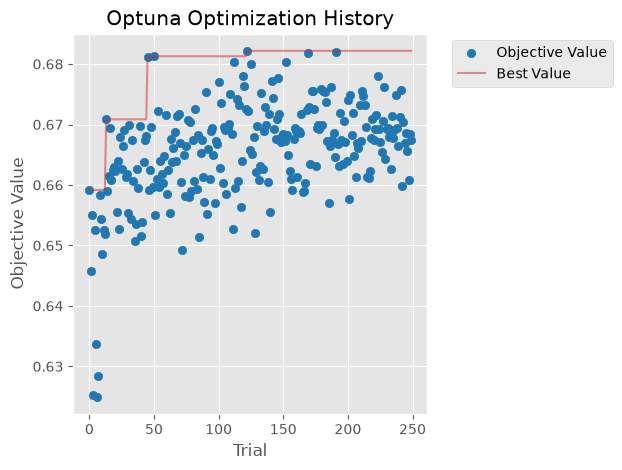

In [12]:
fig = optuna.visualization.matplotlib.plot_optimization_history(study)
plt.title("Optuna Optimization History")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1894378/2144959284.py:1: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_param_importances(study)


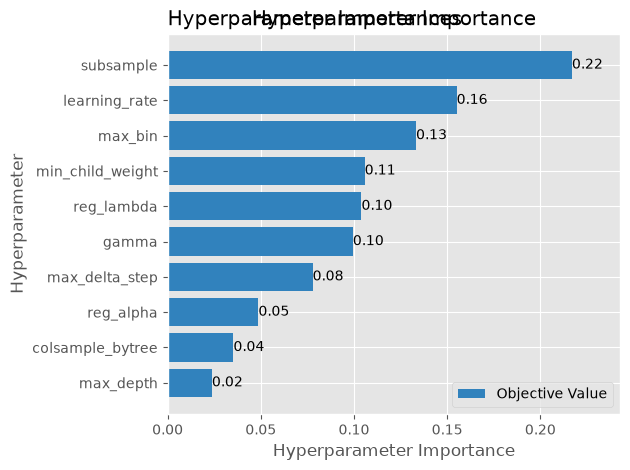

In [13]:
fig = optuna.visualization.matplotlib.plot_param_importances(study)
plt.title("Hyperparameter Importance")
plt.tight_layout()
plt.show()

/tmp/ipykernel_1894378/1725605251.py:1: ExperimentalWarning: optuna.visualization.matplotlib._slice.plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_slice(
/tmp/ipykernel_1894378/1725605251.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


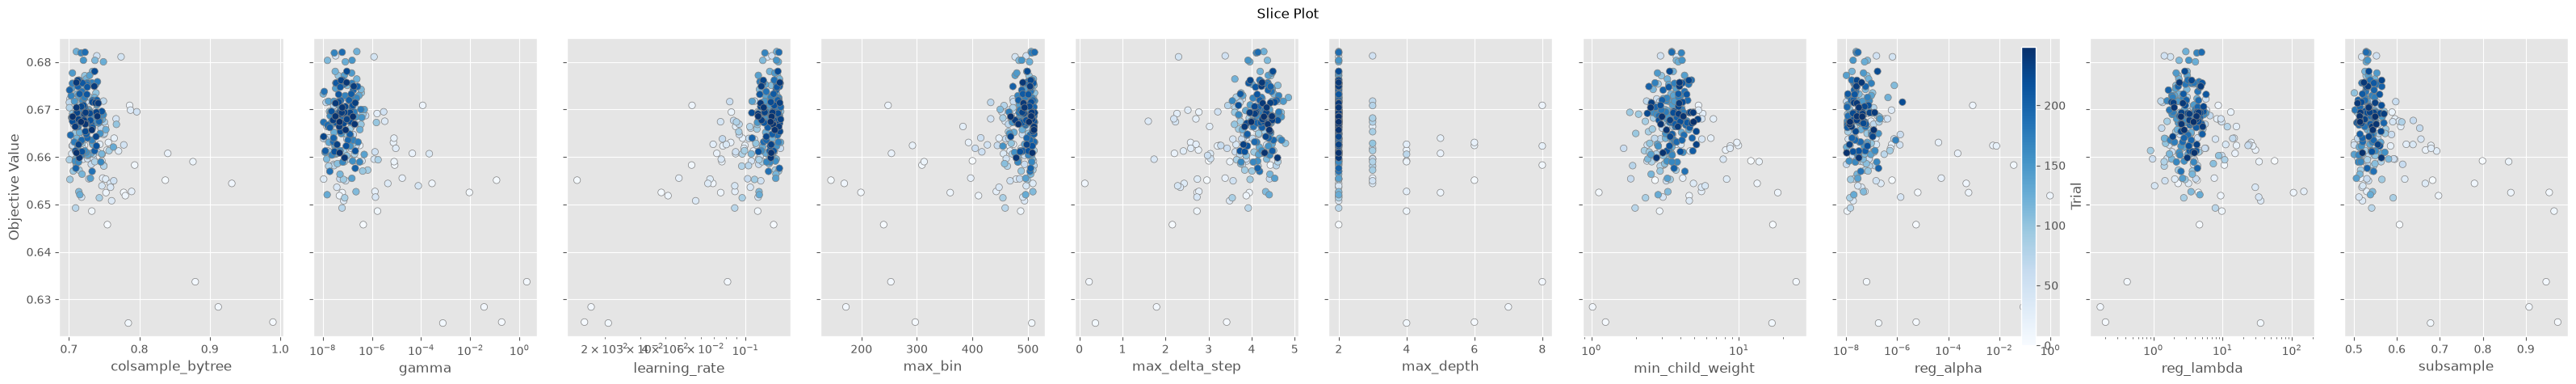

In [14]:
fig = optuna.visualization.matplotlib.plot_slice(
    study,
    params=list(importance_dict.keys())
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1894378/1484866845.py:1: ExperimentalWarning: optuna.visualization.matplotlib._parallel_coordinate.plot_parallel_coordinate is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_parallel_coordinate(


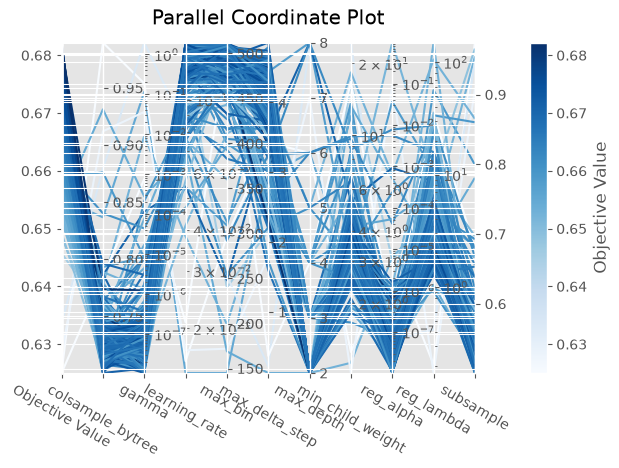

In [15]:
fig = optuna.visualization.matplotlib.plot_parallel_coordinate(
    study,
    params=list(importance_dict.keys())
)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1894378/2829545407.py:1: ExperimentalWarning: optuna.visualization.matplotlib._contour.plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  fig = optuna.visualization.matplotlib.plot_contour(


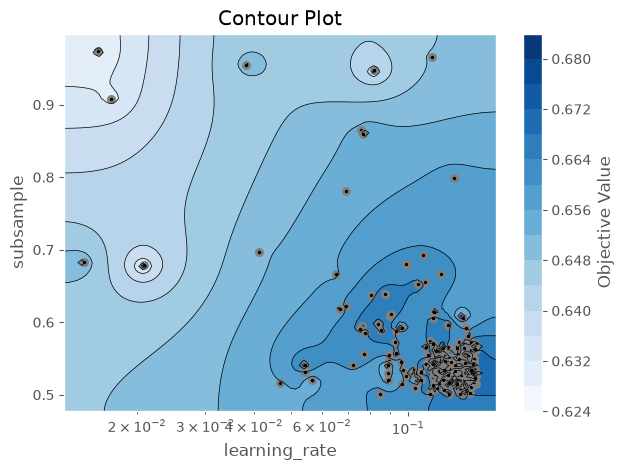

In [16]:
fig = optuna.visualization.matplotlib.plot_contour(
    study,
    params=list(importance_dict.keys())[:2]
)
plt.tight_layout()
plt.show()

In [17]:
trials_df = study.trials_dataframe()

best_trials = (
    trials_df
    .query("state == 'COMPLETE'")
    .sort_values("value", ascending=False)
    .head(10)
)

In [18]:
best_trials

,number,value,datetime_start,datetime_complete,duration,params_colsample_bytree,params_gamma,params_learning_rate,params_max_bin,params_max_delta_step,params_max_depth,params_min_child_weight,params_reg_alpha,params_reg_lambda,params_subsample,system_attrs_tpe:relative_params:0,state
122,122,0.682187,2026-09-10 20:49:48.105969,2026-09-10 20:49:48.377558,0 days 00:00:00.271589,0.710466,2.443683e-07,0.143159,506,4.284484,2,3.508312,2.442512e-08,2.950404,0.528857,"{""colsample_bytree"": 0.710465591534987, ""gamma...",COMPLETE
191,191,0.682039,2026-09-10 20:50:06.636663,2026-09-10 20:50:06.924598,0 days 00:00:00.287935,0.722714,6.190250e-08,0.146844,512,4.147805,2,3.505125,2.892777e-08,4.970450,0.528519,"{""colsample_bytree"": 0.7227138534023011, ""gamm...",COMPLETE
169,169,0.681907,2026-09-10 20:50:01.032982,2026-09-10 20:50:01.462672,0 days 00:00:00.429690,0.717162,2.967810e-08,0.125063,507,4.110720,2,4.077245,2.548821e-08,4.258025,0.533152,"{""colsample_bytree"": 0.7171620632515636, ""gamm...",COMPLETE
50,50,0.681292,2026-09-10 20:49:24.674102,2026-09-10 20:49:24.913069,0 days 00:00:00.238967,0.739521,3.365515e-08,0.135457,497,3.386947,3,2.942119,1.529212e-07,1.442958,0.552582,"{""colsample_bytree"": 0.7395213070571702, ""gamm...",COMPLETE
45,45,0.681082,2026-09-10 20:49:23.224064,2026-09-10 20:49:23.695382,0 days 00:00:00.471318,0.773968,1.224927e-06,0.129131,477,2.303942,2,3.771743,6.523047e-07,1.768125,0.518194,"{""colsample_bytree"": 0.7739683306202085, ""gamm...",COMPLETE
152,152,0.680352,2026-09-10 20:49:56.588990,2026-09-10 20:49:56.885222,0 days 00:00:00.296232,0.720496,1.564962e-07,0.142728,489,3.916917,2,4.120233,1.859063e-08,3.255491,0.532184,"{""colsample_bytree"": 0.7204961807299781, ""gamm...",COMPLETE
112,112,0.680330,2026-09-10 20:49:45.343966,2026-09-10 20:49:45.621934,0 days 00:00:00.277968,0.736885,1.564194e-08,0.122127,484,4.367593,2,3.767118,6.789459e-08,2.356796,0.530059,"{""colsample_bytree"": 0.7368845552626407, ""gamm...",COMPLETE
125,125,0.680029,2026-09-10 20:49:48.898971,2026-09-10 20:49:49.175675,0 days 00:00:00.276704,0.748919,8.340763e-08,0.145857,503,3.960157,2,3.881465,5.253058e-08,4.054466,0.528778,"{""colsample_bytree"": 0.7489187948148679, ""gamm...",COMPLETE
223,223,0.678027,2026-09-10 20:50:17.720892,2026-09-10 20:50:18.044910,0 days 00:00:00.324018,0.736428,9.604097e-08,0.145129,499,4.494074,2,3.395493,1.690029e-07,2.852718,0.534713,"{""colsample_bytree"": 0.7364281238684722, ""gamm...",COMPLETE
119,119,0.678003,2026-09-10 20:49:47.367576,2026-09-10 20:49:47.617130,0 days 00:00:00.249554,0.733347,3.239885e-08,0.132136,498,4.199326,2,3.588123,1.679311e-08,3.078005,0.525905,"{""colsample_bytree"": 0.733346860055786, ""gamma...",COMPLETE


# fit best model

In [19]:
best_params = {
    **study.best_params,
    "objective": "binary:logistic",
    "eval_metric": "auc",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
}

final_model = xgb.XGBClassifier(**best_params)

final_model.fit(X, y, verbose=False)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.710465591534987
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'auc'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


# partial dependence plots

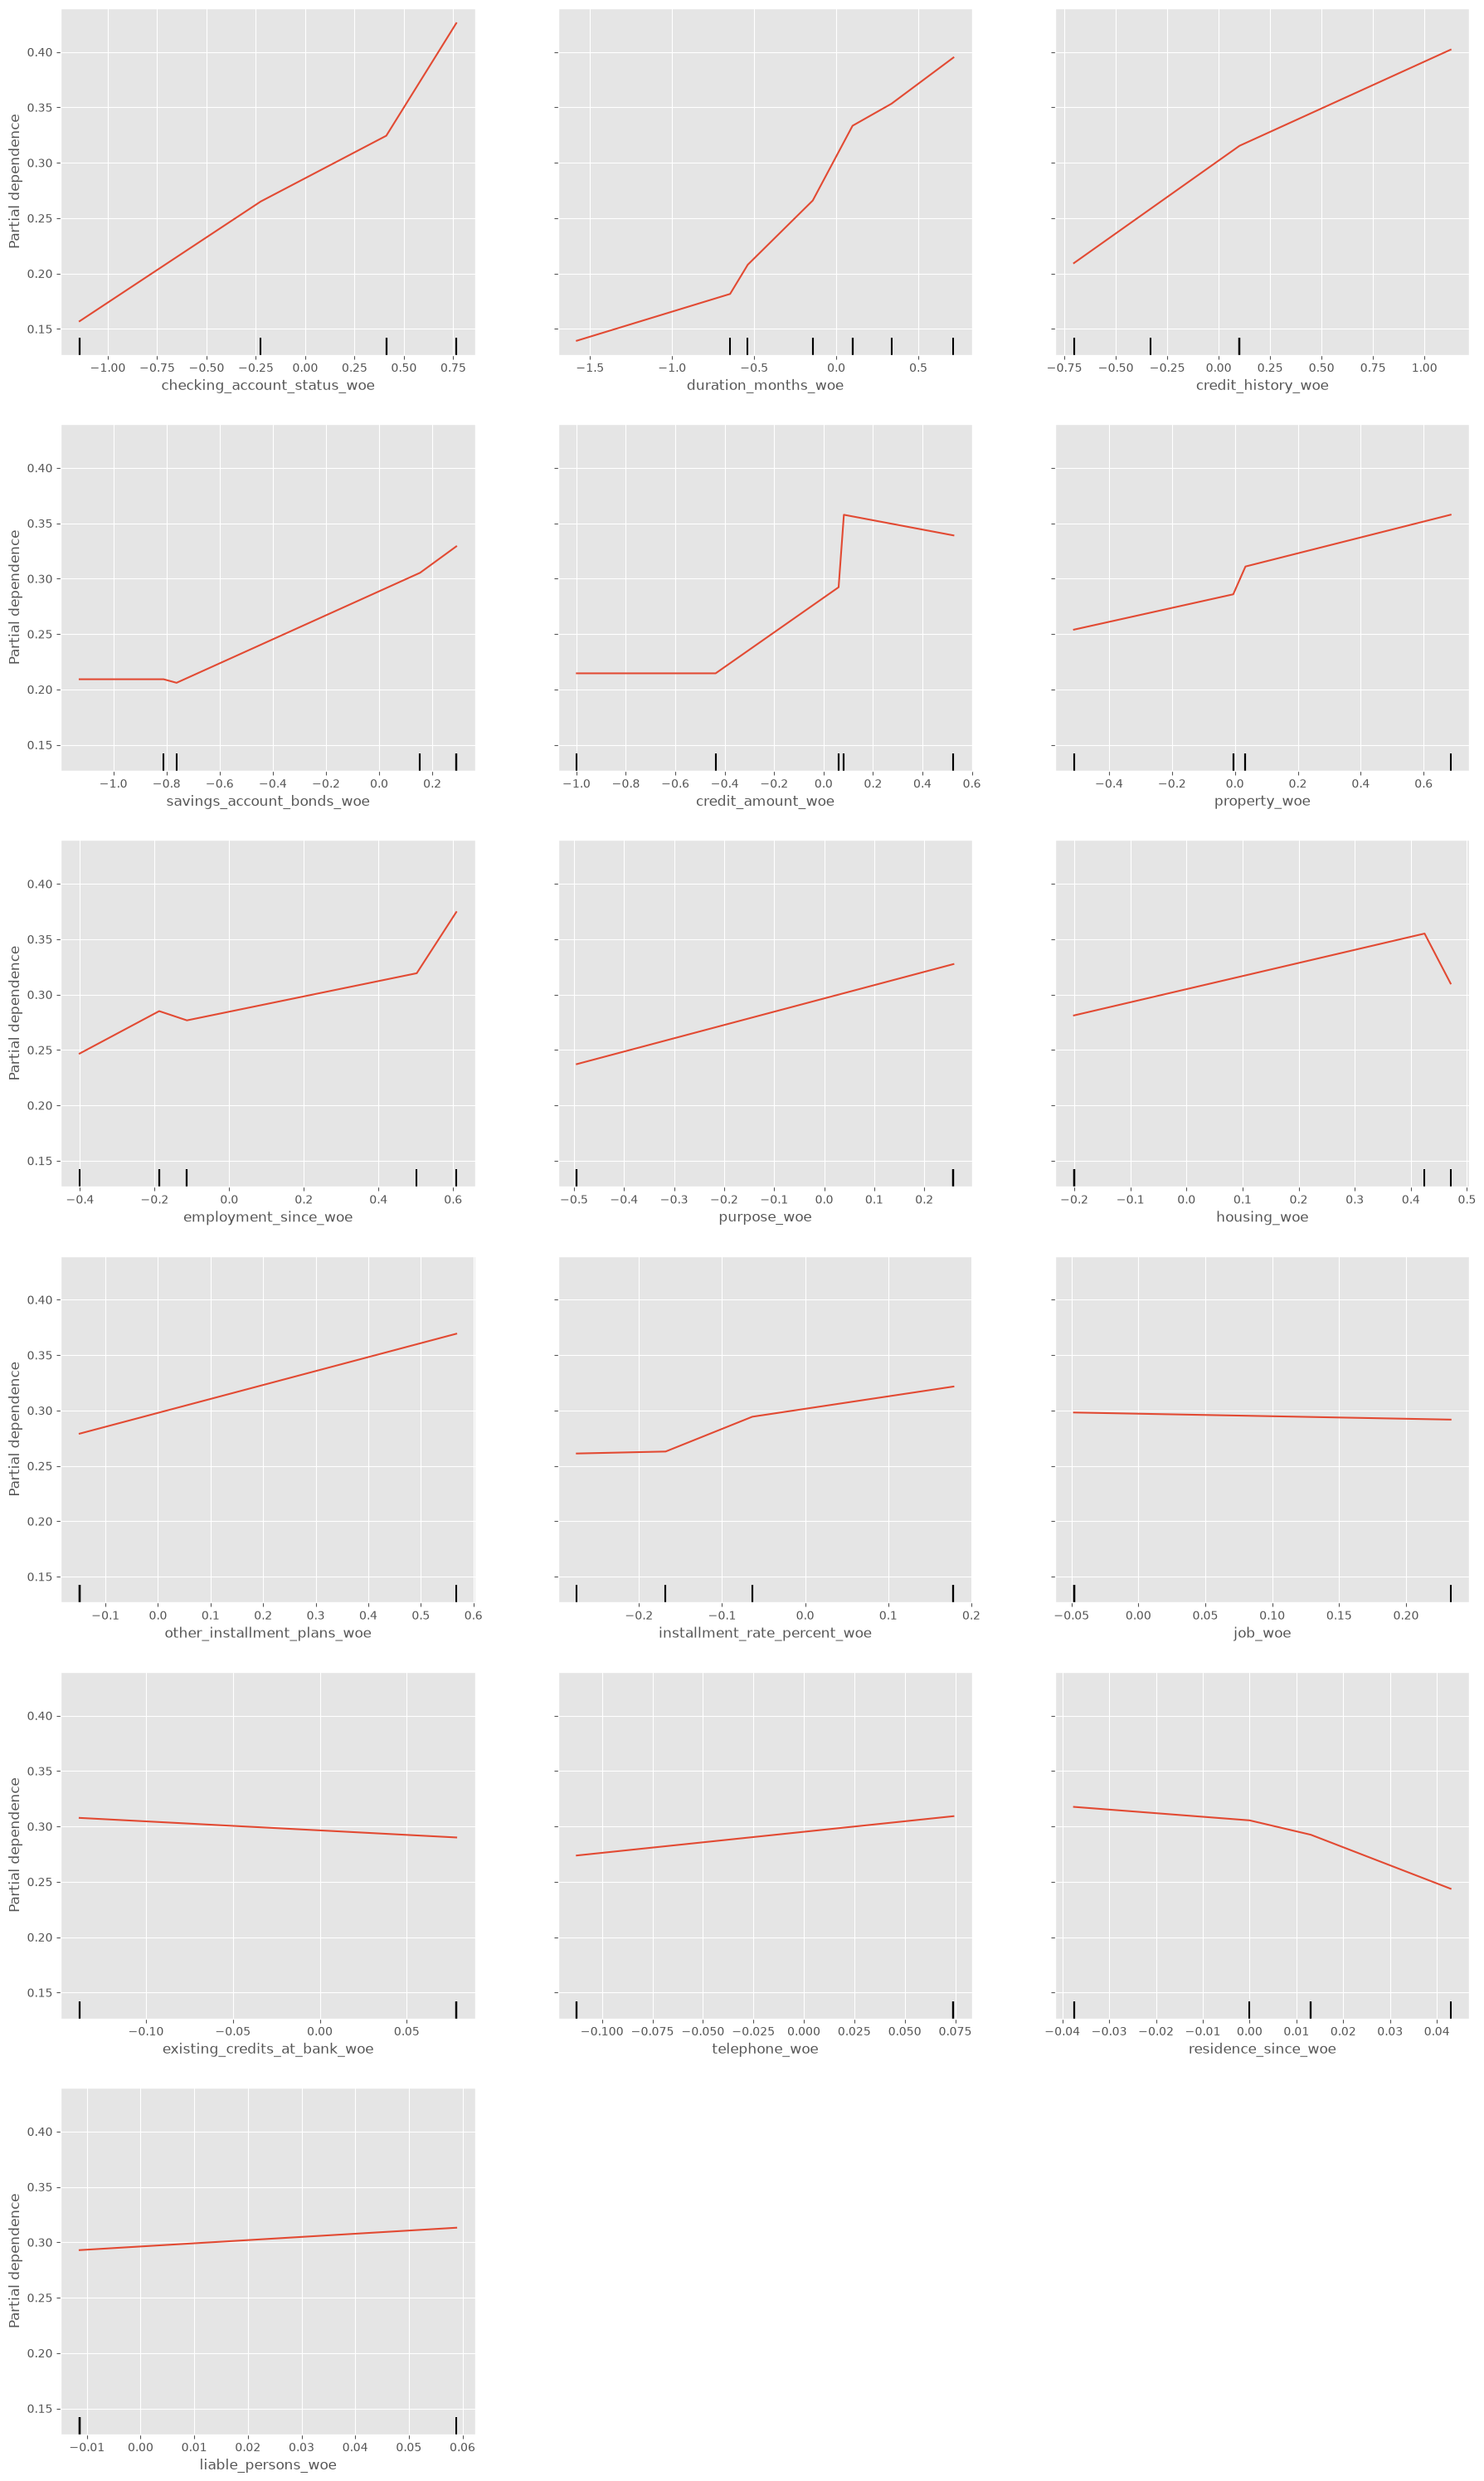

In [20]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay

features = walds["var"].tolist()

display = PartialDependenceDisplay.from_estimator(
    final_model,
    X,
    features=features,
    n_cols=3
)

n_rows = (len(features) + 2) // 3

display.figure_.set_size_inches(
    18,
    5 * n_rows
)

display.figure_.tight_layout()

plt.show()

# save models

In [21]:
models['xgb woe'] = final_model

In [22]:
with open(models_file_path, "wb") as file:
    pickle.dump(models, file)